In [1]:
# Make a scatterplot for an RBP all positions, color each cell line a different color

In [1]:
# Load in packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

In [2]:
path = "/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_first_order_SHAP_analysis/outputs/dpsi_vs_local_SHAP/all_partitions/dpsi_vs_local_SHAP_scatterplot_data_all_partitions.tsv.gz"

In [3]:
table = pd.read_csv(path, sep='\t', compression='gzip')

In [19]:
# Set significance threshold

# Create sig_df with significant events
sig_df = table[
    (table['dPSI'].abs() >= 0.1) & 
    (table['rMATS FDR'] <= 0.05)
].copy()

In [22]:
# Set significance threshold

# Create sig_df with significant events
df = table[
    (table['rMATS FDR'] <= 0.1)
].copy()

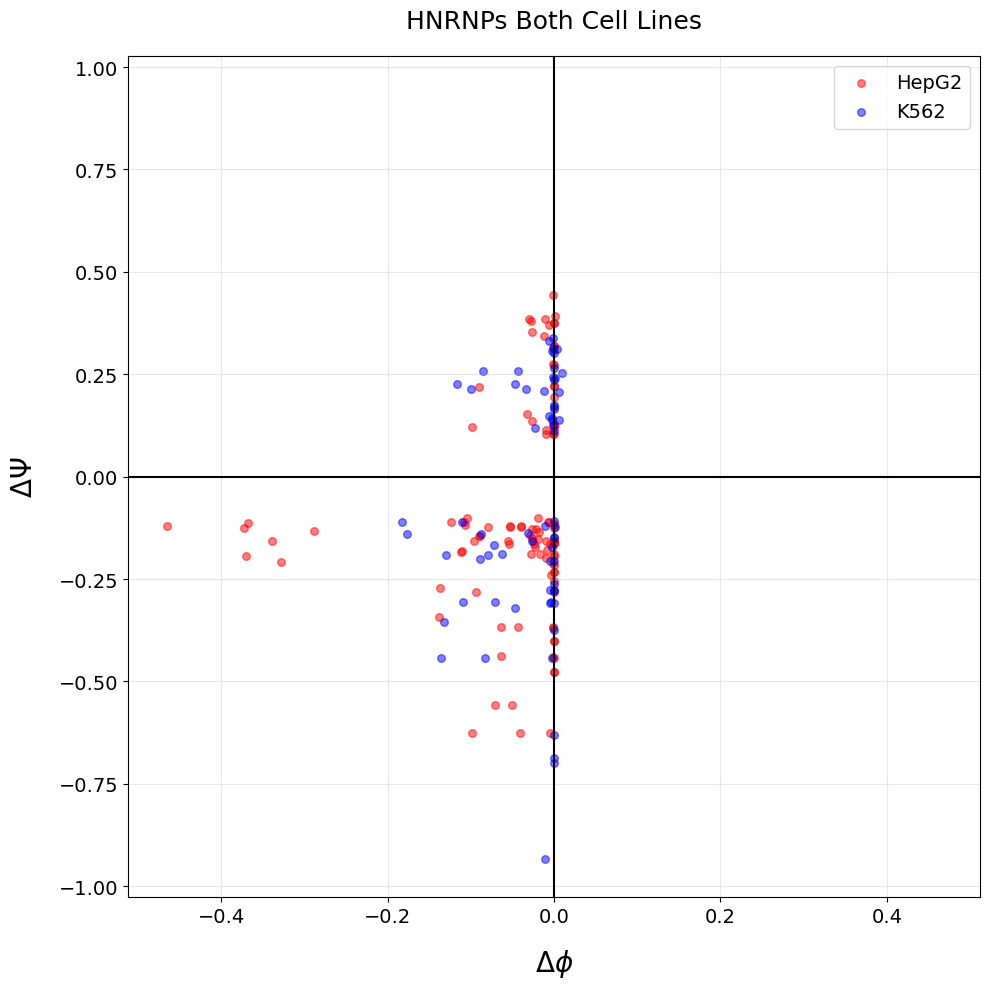

In [13]:
# Scatterplots for the more relaxed significance threshold (dPSI > 0.05, FDR < 0.1)

import matplotlib.pyplot as plt

# Filter the dataframe
plot_df = df[df["Feature"].str.contains("HNRNP", na=False)]

# Create the scatter plot
fig, ax = plt.subplots(figsize=(10, 10))

# Separate data by cell line and plot with different colors
hepg2_data = plot_df[plot_df["Cell Line"] == "HepG2"]
k562_data = plot_df[plot_df["Cell Line"] == "K562"]

ax.scatter(hepg2_data["CTRL - KD Local SHAP"], hepg2_data["dPSI"], 
           alpha=0.5, s=30, color='red', label='HepG2')
ax.scatter(k562_data["CTRL - KD Local SHAP"], k562_data["dPSI"], 
           alpha=0.5, s=30, color='blue', label='K562')

# Add quadrant lines at x=0 and y=0
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)

# Center the axes to show all 4 quadrants
x_max = max(abs(plot_df["CTRL - KD Local SHAP"].min()), abs(plot_df["CTRL - KD Local SHAP"].max()))
y_max = max(abs(plot_df["dPSI"].min()), abs(plot_df["dPSI"].max()))
ax.set_xlim(-x_max * 1.1, x_max * 1.1)
ax.set_ylim(-y_max * 1.1, y_max * 1.1)

# Labels with Greek symbols and title with increased font size and padding
ax.set_xlabel(r"$\Delta\phi$", fontsize=20, labelpad=15)
ax.set_ylabel(r"$\Delta\Psi$", fontsize=20, labelpad=15)
ax.set_title("HNRNPs Both Cell Lines", fontsize=18, pad=20)

# Add legend
ax.legend(fontsize=14)

# Increase tick label font size
ax.tick_params(axis='both', which='major', labelsize=14)

# Add grid
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
def make_all_positions_plot(data, protein, cell_line):
            
    
    plot_df = data[(data["Feature"].str.contains(protein, na=False)) & (data["Cell Line"] == cell_line)]
    
    # Create the scatter plot
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Define colors for each feature
    colors = ['blue', 'green', 'red', 'orange', 'purple', 'cyan']
    feature_names = [f'{protein}_1_binding', f'{protein}_2_binding', f'{protein}_3_binding', 
                     f'{protein}_4_binding', f'{protein}_5_binding', f'{protein}_6_binding']
    
    # Plot each feature with its corresponding color
    for i, feature in enumerate(feature_names):
        feature_data = plot_df[plot_df["Feature"] == feature]
        ax.scatter(feature_data["CTRL - KD Local SHAP"], feature_data["dPSI"], 
                   alpha=0.3, s=20, color=colors[i], label=feature)
    
    # Add quadrant lines at x=0 and y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
    
    # Center the axes to show all 4 quadrants
    x_max = max(abs(plot_df["CTRL - KD Local SHAP"].min()), abs(plot_df["CTRL - KD Local SHAP"].max()))
    y_max = max(abs(plot_df["dPSI"].min()), abs(plot_df["dPSI"].max()))
    ax.set_xlim(-x_max * 1.1, x_max * 1.1)
    ax.set_ylim(-y_max * 1.1, y_max * 1.1)
    
    # Labels with Greek symbols and title with increased font size and padding
    ax.set_xlabel(r"$\Delta\phi$", fontsize=20, labelpad=15)
    ax.set_ylabel(r"$\Delta\Psi$", fontsize=20, labelpad=15)
    ax.set_title(f"{protein} binding in {cell_line}", fontsize=18, pad=20)
    
    # Add legend
    ax.legend(fontsize=12)
    
    # Increase tick label font size
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Add grid
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [13]:
def make_one_position_plot(data, feature, cell_line):

    # Filter the dataframe
    plot_df = data[(data["Feature"] == feature) & (data["Cell Line"] == cell_line)]
    
    # Create the scatter plot
    fig, ax = plt.subplots(figsize=(10, 10))
    
    ax.scatter(plot_df["CTRL - KD Local SHAP"], plot_df["dPSI"], alpha=0.6, s=50)
    
    # Add quadrant lines at x=0 and y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
    
    # Center the axes to show all 4 quadrants
    x_max = max(abs(plot_df["CTRL - KD Local SHAP"].min()), abs(plot_df["CTRL - KD Local SHAP"].max()))
    y_max = max(abs(plot_df["dPSI"].min()), abs(plot_df["dPSI"].max()))
    
    ax.set_xlim(-x_max * 1.1, x_max * 1.1)
    ax.set_ylim(-y_max * 1.1, y_max * 1.1)
    
    # Labels with Greek symbols and title with increased font size and padding
    ax.set_xlabel(r"$\Delta\phi$", fontsize=20, labelpad=15)
    ax.set_ylabel(r"$\Delta\Psi$", fontsize=20, labelpad=15)
    ax.set_title(f"{feature} in {cell_line}", fontsize=18, pad=20)
    
    # Increase tick label font size
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Add grid
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()